# DPR Baseline - Dense Passage Retrieval
Ablasi model retrieval untuk QA produk kecantikan (Shopee, Bahasa Indonesia).
DPR native asymmetric dual-encoder (`facebook/dpr-question_encoder-multiset-base` + `facebook/dpr-ctx_encoder-multiset-base`).
Tiga paradigma (Pointwise, Pairwise, Listwise) dilatih dan dievaluasi dalam satu notebook dengan metrik ranking @k yang identik.

In [1]:
model = 'DPR'

import os
import csv
import time
import pickle
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = '/kaggle/input/datasets/user235162736/shopee-gemastik-v3'
TRAIN_PATH = f'{DATA_DIR}/beauty-product-review-train-v3.csv'
VAL_PATH = f'{DATA_DIR}/beauty-product-review-val-v3.csv'
TEST_PATH = f'{DATA_DIR}/beauty-product-review-test-v3.csv'
WORK_DIR = '/kaggle/working'

Q_ENCODER_NAME = 'facebook/dpr-question_encoder-multiset-base'
CTX_ENCODER_NAME = 'facebook/dpr-ctx_encoder-multiset-base'
DIM = 768
MAX_LEN = 192

K_VALUES = [3, 5, 10]
METRIC_NAMES = ['precision', 'recall', 'f1', 'map', 'ndcg']
PARADIGMS = ['pointwise', 'pairwise', 'listwise']
EPOCHS = 20
BATCH_SIZE = 16
LIST_BATCH = 8
LR = 2e-5
ENC_BATCH = 64
MAX_NEG_PER_POS = 4
TEMP = 0.05
MARGIN = 0.2
TEST_SIZE = 0.15
VAL_SIZE = 0.15
EARLY_STOPPING = True
PATIENCE = 6

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'[{model}] device={DEVICE} q_enc={Q_ENCODER_NAME} ctx_enc={CTX_ENCODER_NAME} epochs={EPOCHS} batch={BATCH_SIZE}')

[DPR] device=cuda q_enc=facebook/dpr-question_encoder-multiset-base ctx_enc=facebook/dpr-ctx_encoder-multiset-base epochs=20 batch=16


In [2]:
def load_split(path):
    df = pd.read_csv(path)
    df['Question_clean'] = df['Question_clean'].fillna('').astype(str)
    df['Answer_clean'] = df['Answer_clean'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)
    df = df[df['Answer_clean'].str.strip() != '']
    return df

train_df = load_split(TRAIN_PATH)
val_df = load_split(VAL_PATH)
test_df = load_split(TEST_PATH)

assert not (set(train_df['product_id']) & set(val_df['product_id']))
assert not (set(train_df['product_id']) & set(test_df['product_id']))
assert not (set(val_df['product_id']) & set(test_df['product_id']))

ANSWER_POOL = train_df['Answer_clean'].unique().tolist()

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'[{model}] {name} rows={len(d)} products={d["product_id"].nunique()} pos={int((d.label == 1).sum())} neg={int((d.label == 0).sum())}')

[DPR] train rows=2200 products=220 pos=570 neg=1630
[DPR] val rows=270 products=27 pos=60 neg=210
[DPR] test rows=280 products=28 pos=79 neg=201


In [3]:
def build_eval(df, split):
    products = {}
    queries = []
    for pid, g in df.groupby('product_id'):
        row_ids = g['ID'].tolist()
        cand = g['Answer_clean'].tolist()
        id_to_pos = {rid: i for i, rid in enumerate(row_ids)}
        products[pid] = cand
        for q, qg in g.groupby('Question_clean'):
            y = np.zeros(len(cand), dtype=np.int32)
            grade = np.zeros(len(cand), dtype=np.float64)
            for _, row in qg.iterrows():
                pos = id_to_pos[row['ID']]
                if int(row['label']) == 1:
                    y[pos] = 1
                    rk = row['rank']
                    grade[pos] = 1.0 / float(rk) if pd.notna(rk) and float(rk) > 0 else 1.0
            if y.sum() == 0:
                continue
            queries.append({'pid': pid, 'question': q, 'y_true': y, 'y_grade': grade, 'n_rel': int(y.sum())})
    sizes = [len(c) for c in products.values()]
    nrels = [qd['n_rel'] for qd in queries]
    print(f'[{model}] {split} products={len(products)} queries={len(queries)} cand/product min={min(sizes)} max={max(sizes)} mean={np.mean(sizes):.1f} n_rel/query min={min(nrels)} max={max(nrels)} mean={np.mean(nrels):.2f}')
    return products, queries

val_products, val_queries = build_eval(val_df, 'val')
test_products, test_queries = build_eval(test_df, 'test')

[DPR] val products=27 queries=27 cand/product min=10 max=10 mean=10.0 n_rel/query min=1 max=6 mean=2.22
[DPR] test products=28 queries=28 cand/product min=10 max=10 mean=10.0 n_rel/query min=1 max=7 mean=2.82


In [4]:
def dcg(gains):
    gains = np.asarray(gains, dtype=np.float64)
    return float(np.sum(gains / np.log2(np.arange(2, gains.size + 2))))

def metrics_at_k(order, y_true, y_grade, k):
    topk = order[:k]
    rel = y_true[topk]
    n_rel = int(y_true.sum())
    hit = int(rel.sum())
    precision = hit / k
    recall = hit / n_rel if n_rel else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    ap = 0.0
    c = 0
    for i, g in enumerate(rel):
        if g:
            c += 1
            ap += c / (i + 1)
    ap = ap / min(n_rel, k) if n_rel else 0.0
    gains = y_grade[topk]
    ideal = np.sort(y_grade)[::-1][:k]
    idcg = dcg(ideal)
    ndcg = dcg(gains) / idcg if idcg else 0.0
    return precision, recall, f1, ap, ndcg

In [5]:
class TrainingLogger:
    def __init__(self, log_path, fieldnames):
        self.log_path = log_path
        self.fieldnames = fieldnames
        if not os.path.exists(log_path):
            with open(log_path, 'w', newline='') as f:
                writer = csv.DictWriter(f, fieldnames=fieldnames)
                writer.writeheader()

    def log(self, row_dict):
        with open(self.log_path, 'a', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=self.fieldnames)
            writer.writerow(row_dict)

LOG_FIELDS = ['epoch', 'step', 'train_loss', 'val_loss', 'val_map_10', 'val_f1_10', 'val_precision_10', 'val_recall_10', 'val_ndcg_3', 'val_ndcg_5', 'val_ndcg_10']

In [6]:
def build_pointwise(df):
    data = [(r['Question_clean'], r['Answer_clean'], float(r['label'])) for _, r in df.iterrows()]
    print(f'[{model}][pointwise] samples={len(data)} pos={int(sum(d[2] for d in data))} neg={int(sum(1 - d[2] for d in data))}')
    return data

def build_pairwise(df, pool):
    data = []
    for pid, g in df.groupby('product_id'):
        prod_neg = g.loc[g.label == 0, 'Answer_clean'].tolist()
        for q, qg in g.groupby('Question_clean'):
            pos = qg.loc[qg.label == 1, 'Answer_clean'].tolist()
            neg = qg.loc[qg.label == 0, 'Answer_clean'].tolist()
            if not neg:
                neg = prod_neg
            for p in pos:
                src = neg if neg else random.sample(pool, min(len(pool), MAX_NEG_PER_POS + 1))
                cands = [n for n in src if n != p]
                for n in random.sample(cands, min(len(cands), MAX_NEG_PER_POS)):
                    data.append((q, p, n))
    print(f'[{model}][pairwise] triples={len(data)}')
    return data

def build_listwise(df):
    data = []
    for pid, g in df.groupby('product_id'):
        cand = list(dict.fromkeys(g['Answer_clean'].tolist()))
        idx = {a: i for i, a in enumerate(cand)}
        for q, qg in g.groupby('Question_clean'):
            pos_idx = [idx[a] for a in set(qg.loc[qg.label == 1, 'Answer_clean'].tolist()) if a in idx]
            if not pos_idx or len(cand) < 2:
                continue
            data.append((q, cand, pos_idx))
    print(f'[{model}][listwise] lists={len(data)}')
    return data

def build_train_data(paradigm, df, pool):
    if paradigm == 'pointwise':
        return build_pointwise(df)
    if paradigm == 'pairwise':
        return build_pairwise(df, pool)
    return build_listwise(df)

In [7]:
from transformers import (DPRQuestionEncoder, DPRContextEncoder,
                          DPRQuestionEncoderTokenizerFast, DPRContextEncoderTokenizerFast)

q_tok = DPRQuestionEncoderTokenizerFast.from_pretrained(Q_ENCODER_NAME)
c_tok = DPRContextEncoderTokenizerFast.from_pretrained(CTX_ENCODER_NAME)

def new_encoders():
    qenc = DPRQuestionEncoder.from_pretrained(Q_ENCODER_NAME).to(DEVICE)
    cenc = DPRContextEncoder.from_pretrained(CTX_ENCODER_NAME).to(DEVICE)
    return qenc, cenc

def embed(encoder, tok, texts):
    enc = tok(list(texts), padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
    return F.normalize(encoder(**enc).pooler_output, dim=-1)

def encode_np(encoder, tok, texts):
    encoder.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), ENC_BATCH):
            out.append(embed(encoder, tok, texts[i:i + ENC_BATCH]).cpu().numpy())
    return np.concatenate(out, 0) if out else np.zeros((0, DIM), dtype=np.float32)

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
def evaluate(qenc, cenc, products, queries, split, paradigm, measure_latency=False):
    prod_emb = {}
    for pid, cand in tqdm(products.items(), desc=f'[{model}][{paradigm}] enc-cand {split}'):
        prod_emb[pid] = encode_np(cenc, c_tok, cand)
    agg = {(m, k): [] for m in METRIC_NAMES for k in K_VALUES}
    latencies = []
    qenc.eval()
    for qd in tqdm(queries, desc=f'[{model}][{paradigm}] eval {split}'):
        emb = prod_emb[qd['pid']]
        t0 = time.perf_counter()
        qv = encode_np(qenc, q_tok, [qd['question']])[0]
        scores = emb @ qv
        order = np.argsort(-scores)
        if measure_latency:
            latencies.append((time.perf_counter() - t0) * 1000.0)
        for k in K_VALUES:
            p, r, f, ap, nd = metrics_at_k(order, qd['y_true'], qd['y_grade'], k)
            agg[('precision', k)].append(p)
            agg[('recall', k)].append(r)
            agg[('f1', k)].append(f)
            agg[('map', k)].append(ap)
            agg[('ndcg', k)].append(nd)
    result = {mk: float(np.mean(v)) for mk, v in agg.items()}
    latency = float(np.mean(latencies)) if latencies else None
    return result, latency

In [9]:
def run_epoch_pointwise(qenc, cenc, opt, data):
    bce = torch.nn.BCEWithLogitsLoss()
    random.shuffle(data)
    losses = []
    for i in tqdm(range(0, len(data), BATCH_SIZE), desc=f'[{model}][pointwise] train'):
        batch = data[i:i + BATCH_SIZE]
        q = [b[0] for b in batch]
        a = [b[1] for b in batch]
        y = torch.tensor([b[2] for b in batch], device=DEVICE)
        logits = (embed(qenc, q_tok, q) * embed(cenc, c_tok, a)).sum(-1) / TEMP
        loss = bce(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))

def run_epoch_pairwise(qenc, cenc, opt, data):
    mr = torch.nn.MarginRankingLoss(margin=MARGIN)
    random.shuffle(data)
    losses = []
    for i in tqdm(range(0, len(data), BATCH_SIZE), desc=f'[{model}][pairwise] train'):
        batch = data[i:i + BATCH_SIZE]
        q = [b[0] for b in batch]
        p = [b[1] for b in batch]
        n = [b[2] for b in batch]
        qe = embed(qenc, q_tok, q)
        sp = (qe * embed(cenc, c_tok, p)).sum(-1) / TEMP
        sn = (qe * embed(cenc, c_tok, n)).sum(-1) / TEMP
        loss = mr(sp, sn, torch.ones_like(sp))
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))

def run_epoch_listwise(qenc, cenc, opt, data):
    random.shuffle(data)
    losses = []
    for i in tqdm(range(0, len(data), LIST_BATCH), desc=f'[{model}][listwise] train'):
        batch = data[i:i + LIST_BATCH]
        opt.zero_grad()
        total = 0.0
        for q, cand, pos_idx in batch:
            qe = embed(qenc, q_tok, [q])[0]
            ce = embed(cenc, c_tok, cand)
            scores = (ce @ qe) / TEMP
            logp = F.log_softmax(scores, dim=0)
            total = total + -(logp[pos_idx].mean())
        loss = total / len(batch)
        loss.backward(); opt.step()
        losses.append(loss.item())
    return float(np.mean(losses))

EPOCH_FN = {'pointwise': run_epoch_pointwise, 'pairwise': run_epoch_pairwise, 'listwise': run_epoch_listwise}

In [10]:
import copy

def train_paradigm(paradigm, data, val_products, val_queries, select_metric=('map', 10)):
    qenc, cenc = new_encoders()
    if len(data) == 0:
        print(f'[{model}][{paradigm}] WARNING empty training data, skip training')
        return qenc, cenc

    opt = torch.optim.AdamW(list(qenc.parameters()) + list(cenc.parameters()), lr=LR)
    logger = TrainingLogger(f'{WORK_DIR}/log_{model}_{paradigm}.csv', LOG_FIELDS)
    steps_per_epoch = int(np.ceil(len(data) / (LIST_BATCH if paradigm == 'listwise' else BATCH_SIZE)))

    best_score = -1.0
    best_state = None
    epochs_no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        qenc.train(); cenc.train()
        train_loss = EPOCH_FN[paradigm](qenc, cenc, opt, data)
        res, _ = evaluate(qenc, cenc, val_products, val_queries, 'val', paradigm)
        logger.log({'epoch': epoch, 'step': epoch * steps_per_epoch, 'train_loss': train_loss, 'val_loss': None,
                    'val_map_10': res[('map', 10)], 'val_f1_10': res[('f1', 10)], 'val_precision_10': res[('precision', 10)],
                    'val_recall_10': res[('recall', 10)], 'val_ndcg_3': res[('ndcg', 3)], 'val_ndcg_5': res[('ndcg', 5)], 'val_ndcg_10': res[('ndcg', 10)]})
        print(f'[{model}][{paradigm}] epoch={epoch} train_loss={train_loss:.4f} val_map@10={res[("map", 10)]:.4f} val_f1@10={res[("f1", 10)]:.4f} val_ndcg@10={res[("ndcg", 10)]:.4f}')

        current_score = res[select_metric]
        if current_score > best_score:
            best_score = current_score
            best_state = {
                'question': copy.deepcopy(qenc.state_dict()),
                'context': copy.deepcopy(cenc.state_dict()),
            }
            epochs_no_improve = 0
            print(f'[{model}][{paradigm}] >>> new best epoch={epoch} {select_metric[0]}@{select_metric[1]}={best_score:.4f}')
        else:
            epochs_no_improve += 1
            if EARLY_STOPPING:
                print(f'[{model}][{paradigm}] no improvement ({epochs_no_improve}/{PATIENCE})')
                if epochs_no_improve >= PATIENCE:
                    print(f'[{model}][{paradigm}] early stopping at epoch={epoch}')
                    break

    qenc.load_state_dict(best_state['question'])
    cenc.load_state_dict(best_state['context'])
    print(f'[{model}][{paradigm}] loaded best checkpoint {select_metric[0]}@{select_metric[1]}={best_score:.4f}')
    return qenc, cenc

In [11]:
records = []
checkpoints = {}
latency_ms = {}

for paradigm in PARADIGMS:
    print(f'\n[{model}] ===== training paradigm: {paradigm} =====')
    data = build_train_data(paradigm, train_df, ANSWER_POOL)
    qenc, cenc = train_paradigm(paradigm, data, val_products, val_queries)

    val_res, _ = evaluate(qenc, cenc, val_products, val_queries, 'val', paradigm)
    test_res, test_lat = evaluate(qenc, cenc, test_products, test_queries, 'test', paradigm, measure_latency=True)
    latency_ms[paradigm] = test_lat

    for split, res in [('val', val_res), ('test', test_res)]:
        for (metric, k), score in res.items():
            records.append({'model': model, 'paradigm': paradigm, 'split': split, 'metric': metric, 'k': k, 'score': score})

    checkpoints[paradigm] = (qenc, cenc)

    print(f'[{model}][{paradigm}] test_latency_ms/query={test_lat:.2f}')
    for split, res in [('val', val_res), ('test', test_res)]:
        print(f'[{model}][{paradigm}] --- {split} ---')
        for k in K_VALUES:
            print(f'[{model}][{paradigm}][{split}] k={k} '
                  f'P={res[("precision", k)]:.4f} R={res[("recall", k)]:.4f} '
                  f'F1={res[("f1", k)]:.4f} MAP={res[("map", k)]:.4f} NDCG={res[("ndcg", k)]:.4f}')


[DPR] ===== training paradigm: pointwise =====
[DPR][pointwise] samples=2200 pos=570 neg=1630


config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

DPRQuestionEncoder LOAD REPORT from: facebook/dpr-question_encoder-multiset-base
Key                                             | Status     |  | 
------------------------------------------------+------------+--+-
question_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 
question_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[DPR][listwise] enc-cand val:   0%|          | 0/27 [00:00<?, ?it/s]

[DPR][listwise] eval val:   0%|          | 0/27 [00:00<?, ?it/s]

[DPR][listwise] enc-cand test:   0%|          | 0/28 [00:00<?, ?it/s]

[DPR][listwise] eval test:   0%|          | 0/28 [00:00<?, ?it/s]

[DPR][listwise] test_latency_ms/query=9.00
[DPR][listwise] --- val ---
[DPR][listwise][val] k=3 P=0.4568 R=0.7099 F1=0.5129 MAP=0.7027 NDCG=0.7259
[DPR][listwise][val] k=5 P=0.3481 R=0.8210 F1=0.4562 MAP=0.7353 NDCG=0.7757
[DPR][listwise][val] k=10 P=0.2222 R=1.0000 F1=0.3467 MAP=0.7961 NDCG=0.8344
[DPR][listwise] --- test ---
[DPR][listwise][test] k=3 P=0.4881 R=0.6104 F1=0.4836 MAP=0.6637 NDCG=0.7379
[DPR][listwise][test] k=5 P=0.4000 R=0.7742 F1=0.4765 MAP=0.6718 NDCG=0.7811
[DPR][listwise][test] k=10 P=0.2821 R=1.0000 F1=0.4116 MAP=0.7546 NDCG=0.8423


In [12]:
log_df = pd.DataFrame(records)
log_df.to_csv(f'{WORK_DIR}/log_{model}.csv', index=False)
print(f'[{model}] saved {WORK_DIR}/log_{model}.csv rows={len(log_df)}')

save_obj = {
    'model': model,
    'q_encoder_name': Q_ENCODER_NAME,
    'ctx_encoder_name': CTX_ENCODER_NAME,
    'k_values': K_VALUES,
    'results': records,
    'latency_ms': latency_ms,
    'state_dicts': {p: {'question': {k: v.cpu() for k, v in checkpoints[p][0].state_dict().items()},
                        'context': {k: v.cpu() for k, v in checkpoints[p][1].state_dict().items()}} for p in checkpoints},
}
with open(f'{WORK_DIR}/bprqa_{model}.pkl', 'wb') as f:
    pickle.dump(save_obj, f)
print(f'[{model}] saved {WORK_DIR}/bprqa_{model}.pkl')

[DPR] saved /kaggle/working/log_DPR.csv rows=90
[DPR] saved /kaggle/working/bprqa_DPR.pkl


In [13]:
summary = log_df.pivot_table(index=['paradigm', 'metric', 'k'], columns='split', values='score').reset_index()
summary = summary.sort_values(['paradigm', 'metric', 'k']).reset_index(drop=True)
print(f'[{model}] evaluation summary (val vs test)')
print(summary.to_string(index=False))
print(f'\n[{model}] mean test latency ms/query per paradigm:')
for p in PARADIGMS:
    print(f'[{model}][{p}] {latency_ms[p]:.2f} ms')

[DPR] evaluation summary (val vs test)
 paradigm    metric  k     test      val
 listwise        f1  3 0.483588 0.512875
 listwise        f1  5 0.476474 0.456242
 listwise        f1 10 0.411614 0.346730
 listwise       map  3 0.663690 0.702675
 listwise       map  5 0.671845 0.735340
 listwise       map 10 0.754569 0.796083
 listwise      ndcg  3 0.737904 0.725861
 listwise      ndcg  5 0.781105 0.775732
 listwise      ndcg 10 0.842314 0.834449
 listwise precision  3 0.488095 0.456790
 listwise precision  5 0.400000 0.348148
 listwise precision 10 0.282143 0.222222
 listwise    recall  3 0.610374 0.709877
 listwise    recall  5 0.774235 0.820988
 listwise    recall 10 1.000000 1.000000
 pairwise        f1  3 0.500255 0.538977
 pairwise        f1  5 0.543707 0.462241
 pairwise        f1 10 0.411614 0.346730
 pairwise       map  3 0.672619 0.692387
 pairwise       map  5 0.735486 0.717181
 pairwise       map 10 0.784281 0.772354
 pairwise      ndcg  3 0.701562 0.693056
 pairwise      ndc

/tmp/ipykernel_23/4279040854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_23/4279040854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_23/4279040854.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


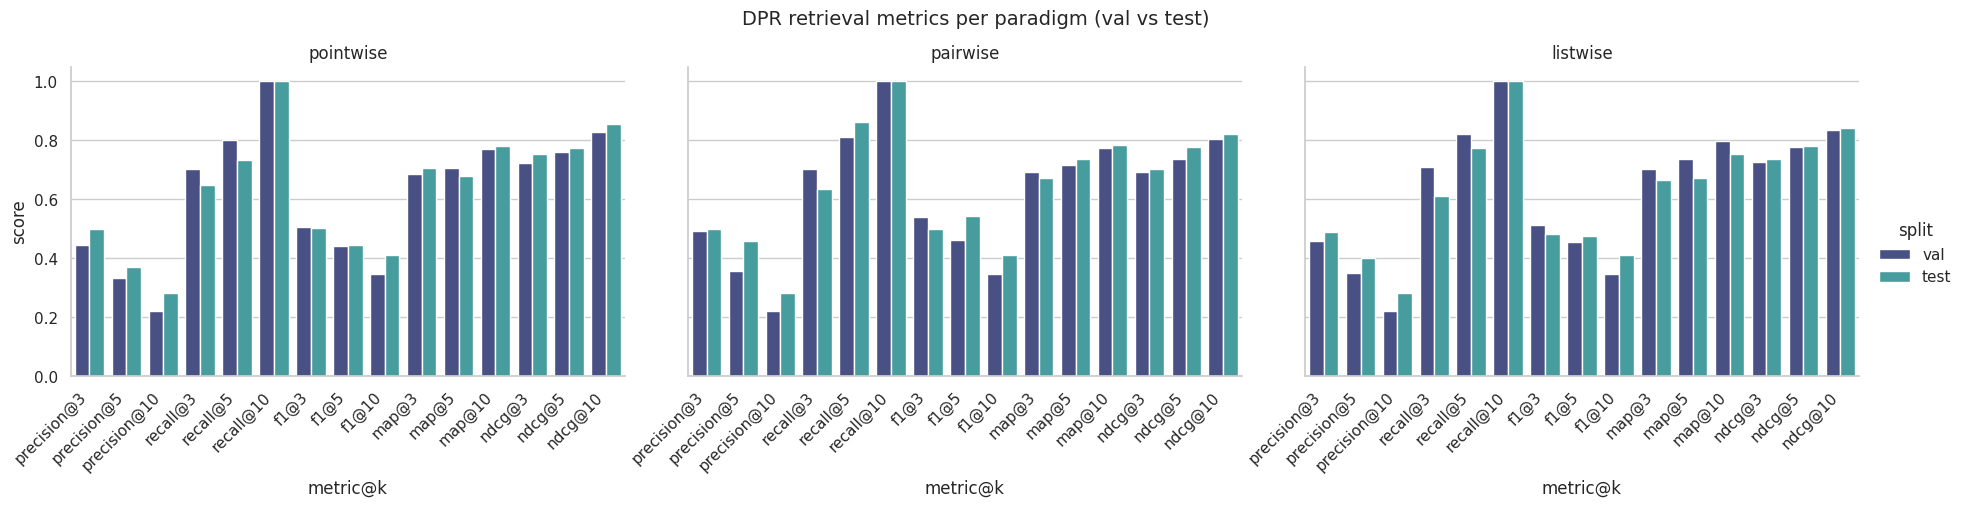

[DPR] saved /kaggle/working/plot_DPR.png


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plot_df = log_df.copy()
plot_df['metric_k'] = plot_df['metric'] + '@' + plot_df['k'].astype(str)
metric_order = [f'{m}@{k}' for m in METRIC_NAMES for k in K_VALUES]

g = sns.catplot(data=plot_df, x='metric_k', y='score', hue='split', col='paradigm', kind='bar',
                palette='mako', order=metric_order, col_order=PARADIGMS, height=4.2, aspect=1.5)
g.set_axis_labels('metric@k', 'score')
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
g.fig.suptitle(f'{model} retrieval metrics per paradigm (val vs test)', y=1.04, fontsize=14)
g.savefig(f'{WORK_DIR}/plot_{model}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[{model}] saved {WORK_DIR}/plot_{model}.png')